# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.1 Introduction 
Credit risk assessment is a crucial task for financial institutions. Accurately predicting whether a borrower will default on a loan helps banks reduce losses, manage risk, and make better lending decisions. Machine learning models, especially ensemble methods like Random Forest and XGBoost, can capture complex patterns in borrower data to improve prediction accuracy.</b></div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.2 Problem Statement 
Given a dataset of loan applicants, including demographic, financial, and loan-specific features, the goal is to predict whether a borrower will default (loan_status). Early prediction of default can help lenders minimize financial risk.</b></div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.3 Data set Info
</b></div>

### Target Variable:
- **loan_status**: Indicates whether the borrower defaulted (1 = Default, 0 = No Default)

### Categorical Features:
- **person_home_ownership**: Type of home ownership (e.g., RENT, OWN, MORTGAGE)
- **loan_intent**: Purpose of the loan (e.g., EDUCATION, MEDICAL, PERSONAL, HOMEIMPROVEMENT)
- **loan_grade**: Risk grade assigned to the loan by lender (A to G)
- **cb_person_default_on_file**: Whether the borrower has any prior default on file (Y/N)

### Numerical Features:
- **person_age**: Age of the borrower (years)
- **person_income**: Annual income of the borrower (USD)
- **person_emp_length**: Years of employment
- **loan_amnt**: Loan amount requested (USD)
- **loan_int_rate**: Interest rate of the loan (%)
- **loan_percent_income**: Loan amount as a percentage of borrower’s income
- **cb_person_cred_hist_length**: Length of borrower’s credit history (months)



# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.4 Data Load and Check</b></div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df = pd.read_csv('../Dataset/credit_risk_data.csv')
df.head()


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0.0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1.0,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2.0,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3.0,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4.0,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [23]:
print("Shape:", df.shape)

display(df.head())

display(df.info())

display(df.describe())



Shape: (91226, 13)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0.0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1.0,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2.0,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3.0,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4.0,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91226 entries, 0 to 91225
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  float64
 1   person_age                  91226 non-null  int64  
 2   person_income               91226 non-null  int64  
 3   person_home_ownership       91226 non-null  object 
 4   person_emp_length           90331 non-null  float64
 5   loan_intent                 91226 non-null  object 
 6   loan_grade                  91226 non-null  object 
 7   loan_amnt                   91226 non-null  int64  
 8   loan_int_rate               88110 non-null  float64
 9   loan_percent_income         91226 non-null  float64
 10  cb_person_default_on_file   91226 non-null  object 
 11  cb_person_cred_hist_length  91226 non-null  int64  
 12  loan_status                 91226 non-null  int64  
dtypes: float64(4), int64(5), object

None

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,91226.000000,9.122600e+04,90331.000000,91226.000000,88110.000000,91226.000000,91226.000000,91226.000000
mean,29322.000000,27.616480,6.477071e+04,4.732119,9350.348607,10.789508,0.163154,5.810219,0.169447
std,16929.497605,6.148115,4.793696e+04,4.025068,5848.605423,3.108998,0.097491,4.038412,0.375149
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.000000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.700000e+04,4.000000,8000.000000,10.950000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.800000e+04,7.000000,12000.000000,13.110000,0.220000,8.000000,0.000000
max,58644.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


## Null Check

In [24]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
id                            32581
person_age                        0
person_income                     0
person_home_ownership             0
person_emp_length               895
loan_intent                       0
loan_grade                        0
loan_amnt                         0
loan_int_rate                  3116
loan_percent_income               0
cb_person_default_on_file         0
cb_person_cred_hist_length        0
loan_status                       0
dtype: int64


In [25]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].mean())

## Duplicate Check

In [26]:

df_no_id = df.drop(columns=["id"])
num_duplicates = df_no_id.duplicated().sum()
df = df.drop_duplicates(subset=df_no_id.columns, keep='first')
print("Number of duplicate rows Before :", num_duplicates)
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows After :", num_duplicates)

Number of duplicate rows Before : 165
Number of duplicate rows After : 0


## Range Check

In [27]:

ranges = {
    "person_age": (18, 100),
    "person_income": (0, 1_000_000),  
    "person_emp_length": (0, 60),     
    "loan_amnt": (500, 1_000_000),   
    "loan_int_rate": (0, 30),           
    "loan_percent_income": (0, 1),     
    "cb_person_cred_hist_length": (0, 100),  
    "loan_status": (0, 1)              
}

print("\n🔢 Checking numerical values range...\n")

for col, (low, high) in ranges.items():
    if col in df.columns:
        
        outliers = df[(df[col] < low) | (df[col] > high)][col]
        if not outliers.empty:
            print(f"⚠️ {col} out of range values: {outliers.unique()}\n")
        else:
            print(f"✅ {col} is within range")


🔢 Checking numerical values range...

⚠️ person_age out of range values: [123 144]

⚠️ person_income out of range values: [1200000 1839784 1900000 1824000 2039784 1362000 1440000 6000000 1782000]

⚠️ person_emp_length out of range values: [123.]

✅ loan_amnt is within range
✅ loan_int_rate is within range
✅ loan_percent_income is within range
✅ cb_person_cred_hist_length is within range
✅ loan_status is within range


#### Data Cleaning Decision:
The dataset contains some extreme values in the numerical columns. In person_age and person_emp_length, values such as 123 or 144 are highly likely to be errors while entries, so these rows will be removed from the dataset. For person_income, although a few entries are unusually high, they may represent genuine high-income cases, so we will keep them for now and consider handling them later using scaling or a log transformation if needed.

In [28]:
df=df[df['person_age'] <= 100]
df=df[df['person_emp_length'] <= 60]

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.5 EDA
</b></div>

In [29]:

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['id']).tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']


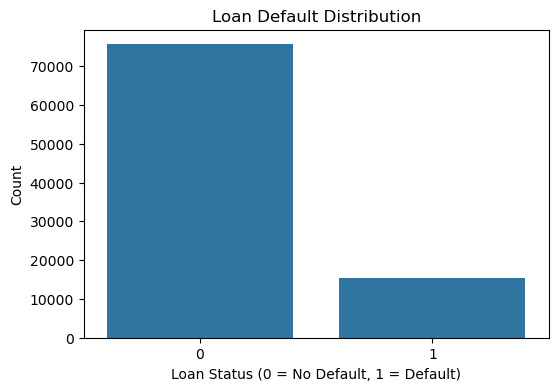

Default Rate: 16.954234440039098 %


In [30]:
# Target variable distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Count")

plt.show()

print("Default Rate:", df["loan_status"].mean()*100,"%")

Target is not balanced

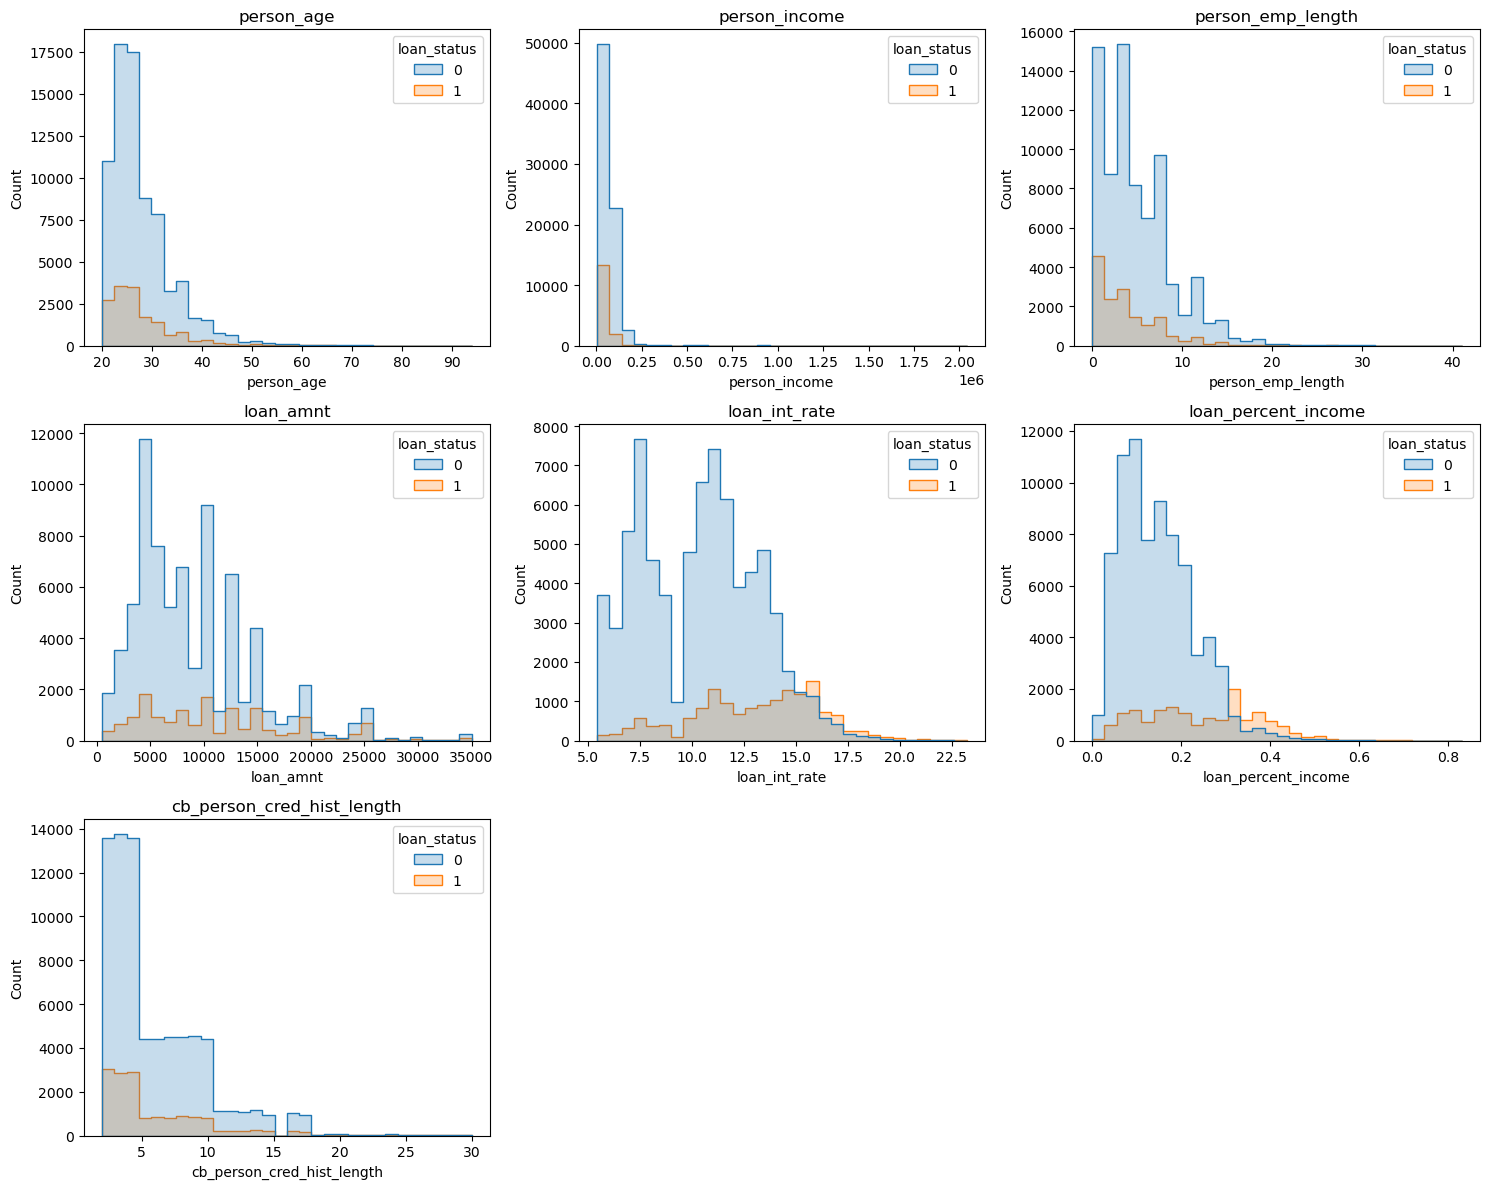

In [31]:
num_cols = [
'person_age','person_income','person_emp_length','loan_amnt','loan_int_rate',
'loan_percent_income','cb_person_cred_hist_length'
]

n_cols = 3
n_rows = (len(num_cols)+n_cols-1)//n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.ravel()

for i,col in enumerate(num_cols):
    
    sns.histplot(data=df, x=col, hue="loan_status",bins=30, ax=axes[i], element="step")
    
    axes[i].set_title(col)

for j in range(i+1,len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

### Some findings:
- Most borrowers are between 20–40 years old, and younger people default more.
- People with less work experience are more likely to default.
- Higher loan amounts show a slight increase in default, but not very strong.
- Interest rate is important:
  - Lower rates (8–12%) → fewer defaults
  - Higher rates (12–18%) → more defaults
- Loan percent income is the strongest factor:
  - Low (<0.2) → safer
  - High (0.3–0.6+) → higher default risk
- People with longer credit history are safer, while short history (2–6 years) has more defaults

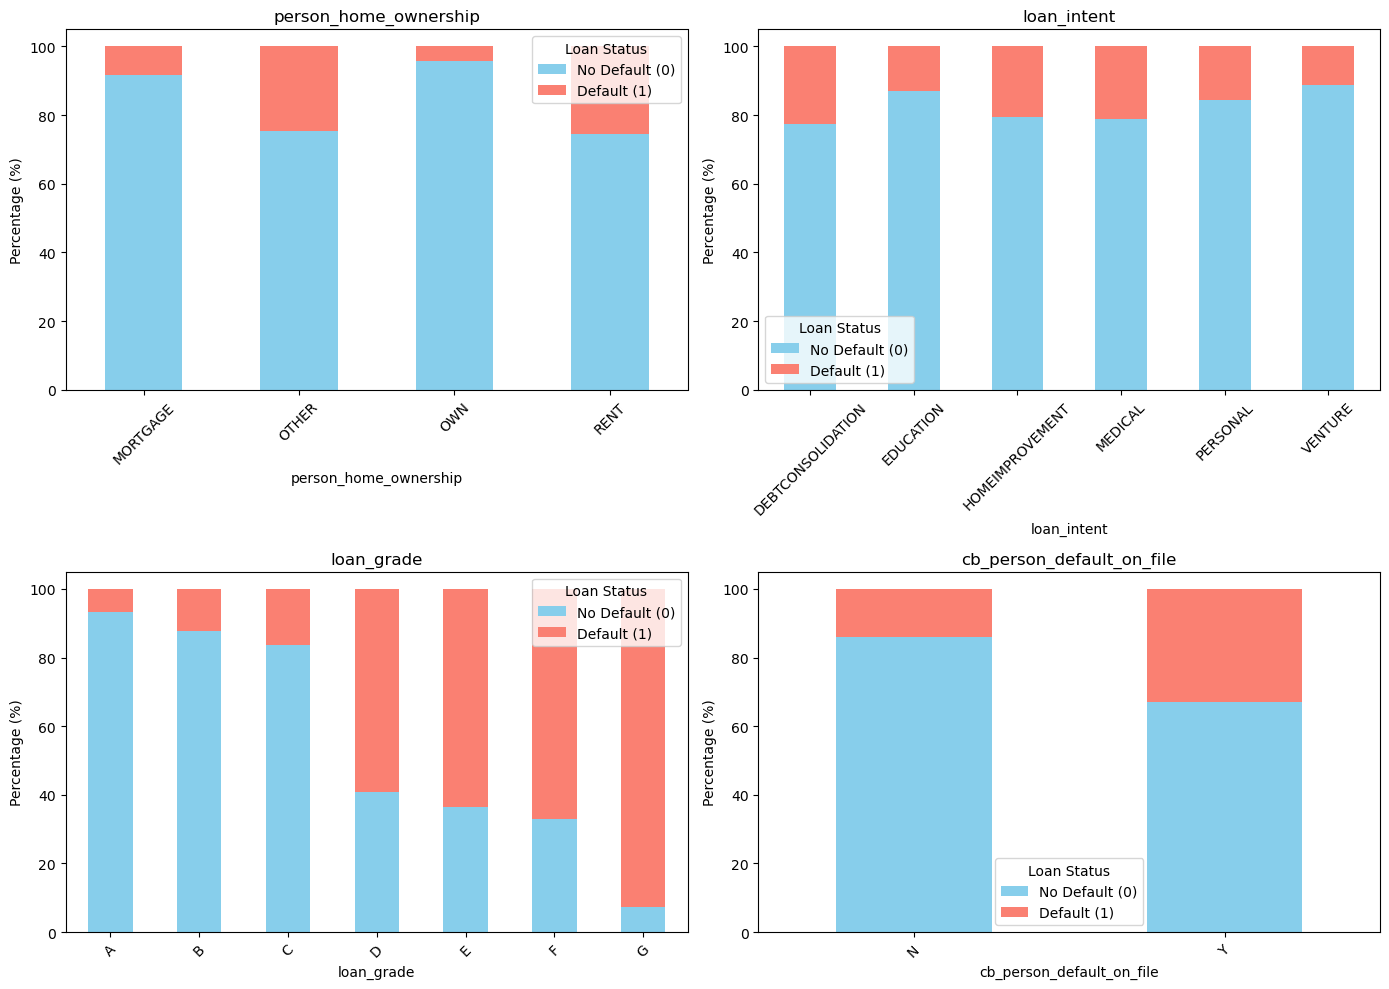

In [32]:

cat_cols = [
'person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'
]

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.ravel()

for i,col in enumerate(cat_cols):
    
    temp = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    temp.plot(kind='bar', stacked=True, ax=axes[i],color=['skyblue', 'salmon'])
    
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend(title='Loan Status', labels = ['No Default (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

### Some key insights: 
<div style="background-color: #11111b; padding: 20px; border-radius: 12px; border: 1px solid #313244; color: #cdd6f4; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; width: 95%; margin: 10px auto;">

<table style="width: 100%; border-collapse: collapse; table-layout: auto;">
<thead>
<tr style="border-bottom: 3px solid #45475a;">
<th style="text-align: left; padding: 12px; color: #89b4fa; font-size: 1.1em;">Category</th>
<th style="text-align: left; padding: 12px; color: #a6e3a1; font-size: 1.1em;">Low Risk ✅</th>
<th style="text-align: left; padding: 12px; color: #fab387; font-size: 1.1em;">Moderate ⚠️</th>
<th style="text-align: left; padding: 12px; color: #f38ba8; font-size: 1.1em;">High Risk 🚨</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid #313244;">
<td style="padding: 15px;"><b>🏠 Home Ownership</b></td>
<td style="padding: 15px;">OWN</td>
<td style="padding: 15px;">MORTGAGE</td>
<td style="padding: 15px;">RENT</td>
</tr>
<tr style="border-bottom: 1px solid #313244;">
<td style="padding: 15px;"><b>🎯 Loan Purpose</b></td>
<td style="padding: 15px;">Education / Venture</td>
<td style="padding: 15px;">Home Improvement</td>
<td style="padding: 15px;">Medical / Debt Consolidation</td>
</tr>
<tr style="border-bottom: 1px solid #313244;">
<td style="padding: 15px;"><b>📉 Loan Grade</b></td>
<td style="padding: 15px;">A & B (Prime)</td>
<td style="padding: 15px;">C (Mid-tier)</td>
<td style="padding: 15px;">D, E, F, G (Subprime)</td>
</tr>
<tr>
<td style="padding: 15px;"><b>🚩 Default History</b></td>
<td style="padding: 15px;">No (N)</td>
<td style="padding: 15px;">—</td>
<td style="padding: 15px; color: #f38ba8;"><b>Yes (Y) - Critical Flag</b></td>
</tr>
</tbody>
</table>

<div style="margin-top: 20px; padding: 15px; background-color: #181825; border-left: 5px solid #f38ba8; border-radius: 4px; font-size: 1em; line-height: 1.6;">
<strong style="color: #f38ba8;">Final Insight:</strong> Borrowers with higher loan burden, higher interest rates, lower credit grades, and previous defaults are more likely to default. In contrast, individuals with stable income, longer credit history, and home ownership tend to be safer.
</div>

</div>

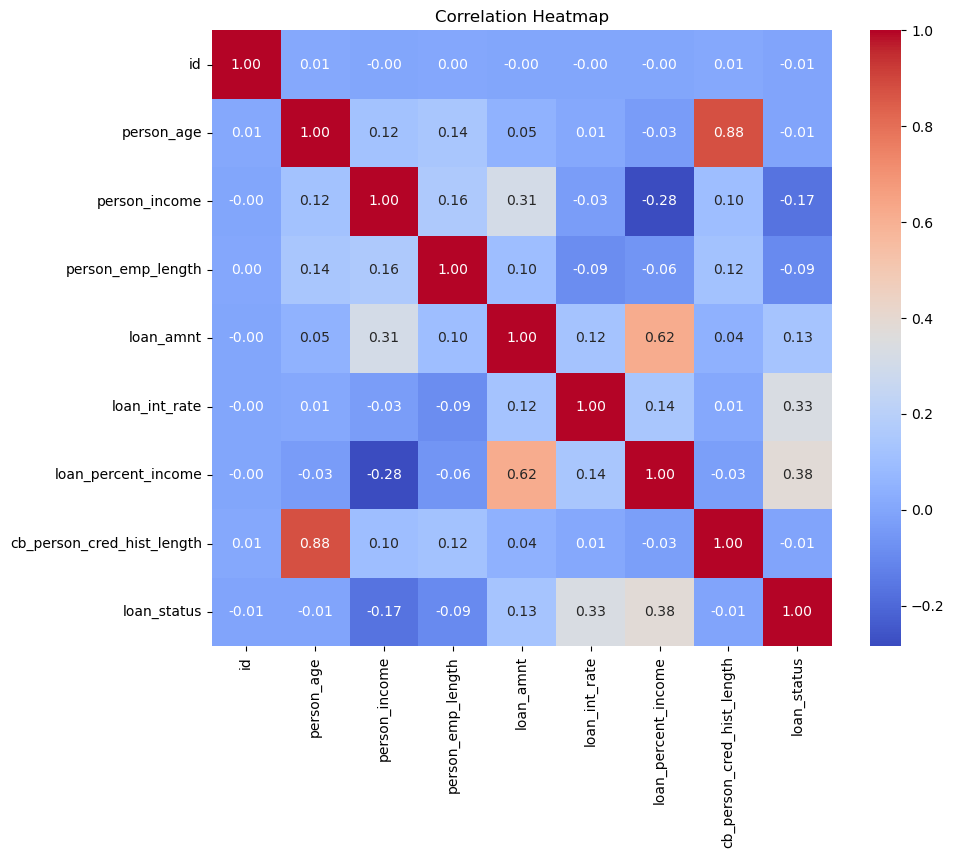

In [33]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
df.to_csv('../Dataset/credit_risk_data_cleaned.csv', index=False)